# 🕵️‍♂️ Credit Card Fraud Detection Project
This notebook analyzes anonymized credit card transactions to detect fraudulent cases. We experiment with multiple machine learning models, handle class imbalance, and visualize performance metrics for better fraud detection insights.

Importing NumPy (numerical operations) and Pandas (data handling).

In [1]:
import numpy as np
import pandas as pd

Importing Matplotlib and Seaborn Library for Data Plotting and Visualisation

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Dataset into variable called credit_card_data

In [3]:
credit_card_data = pd.read_csv('creditcard.csv')
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Checking for null and missing values in each column

In [4]:
credit_card_data.info()
credit_card_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### ⚖️ Class Distribution
- `0` → Normal transactions
- `1` → Fraudulent transactions
Fraud cases are **extremely rare (~0.17%)**, leading to a class imbalance problem.

In [5]:
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Plotting the distribution of Normal Vs Fraud Transactions

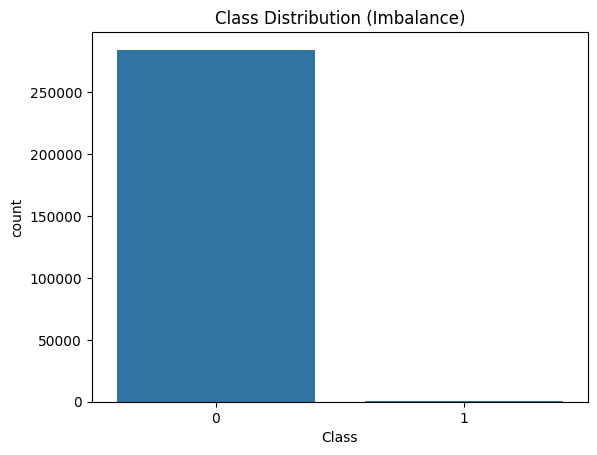

In [6]:
sns.countplot(x='Class', data=credit_card_data)
plt.title('Class Distribution (Imbalance)')
plt.show()

In [7]:
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


Statistical Summary Of Normal Transactions

In [8]:
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Statistical Summary Of Fruad Transactions

In [9]:
fraud.Amount.describe()


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Compares average values of each feature between fraud and Normal classes

In [10]:
credit_card_data.groupby('Class').mean()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Importing Scikit Learn Library and use it for:
* Splitting dataset
* Logistic Regression model
* Accuracy,confusion matrix,scores evaluation
* Random Forest Model
* Xgboost Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from imblearn.over_sampling import SMOTE

In [12]:
X=credit_card_data.drop(columns='Class', axis=1)
Y=credit_card_data['Class']

Splitting the dataset into training,testing data

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)


(284807, 30) (227845, 30) (56962, 30)


Importing SMOTE (Synthetic Minority Over-sampling Technique).

Balancing dataset by generating synthetic fraud samples.

In [14]:
sm = SMOTE(random_state=2)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)
print('After SMOTE:', X_train_res.shape, Y_train_res.value_counts())

After SMOTE: (454902, 30) Class
0    227451
1    227451
Name: count, dtype: int64


In [15]:
results = {}

Importing 3 different machine learning models and analysing on the dataset

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=2),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [17]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_res, Y_train_res)
    y_pred = model.predict(X_test)


    acc = accuracy_score(Y_test, y_pred)
    auc = roc_auc_score(Y_test, model.predict_proba(X_test)[:, 1])

    results[name] = {'Accuracy': acc, 'AUC': auc}

    print(f"\n{name} Results:")
    print(classification_report(Y_test, y_pred))


Training Logistic Regression...


C:\Users\vm336\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.14      0.93      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.96      0.62     56962
weighted avg       1.00      0.99      0.99     56962


Training Random Forest...

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.86      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Training XGBoost...


C:\Users\vm336\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [18:49:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



Getting The Accuracy of all 3 models

In [18]:
results

{'Logistic Regression': {'Accuracy': 0.9899231066324918,
  'AUC': np.float64(0.9891516134450404)},
 'Random Forest': {'Accuracy': 0.9994908886626171,
  'AUC': np.float64(0.9806906812387306)},
 'XGBoost': {'Accuracy': 0.999385555282469,
  'AUC': np.float64(0.9812949694509205)}}

                     Accuracy       AUC
Logistic Regression  0.989923  0.989152
Random Forest        0.999491  0.980691
XGBoost              0.999386  0.981295


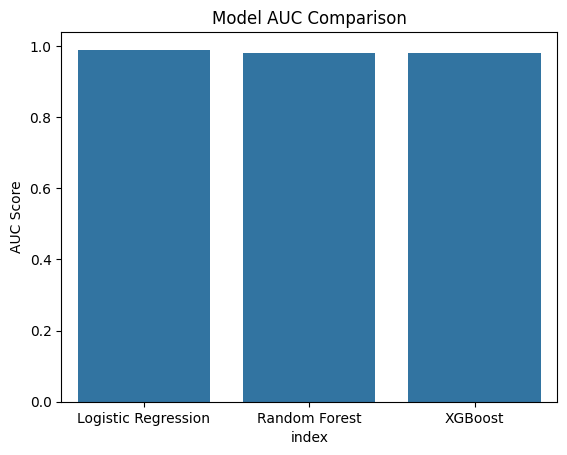

In [19]:
results_df = pd.DataFrame(results).T
print(results_df)

sns.barplot(data=results_df.reset_index(), x='index', y='AUC')
plt.title('Model AUC Comparison')
plt.ylabel('AUC Score')
plt.show()

Generating the Confusion matrix of all 3 models

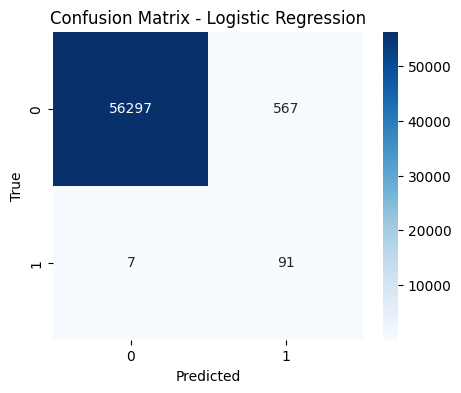

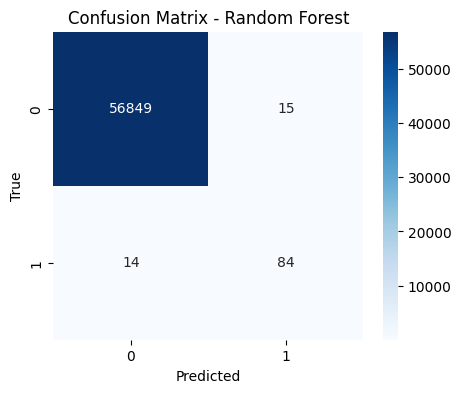

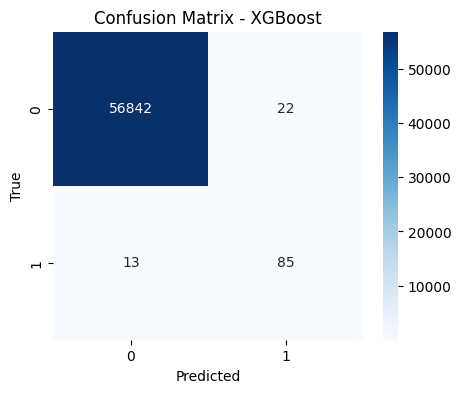

In [20]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


Plotting the ROC,Precision Recall Curves

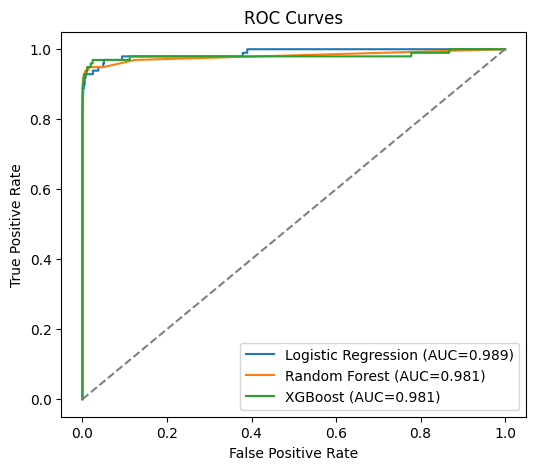

In [21]:
plt.figure(figsize=(6,5))

for name, model in models.items():
    fpr, tpr, _ = roc_curve(Y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(Y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

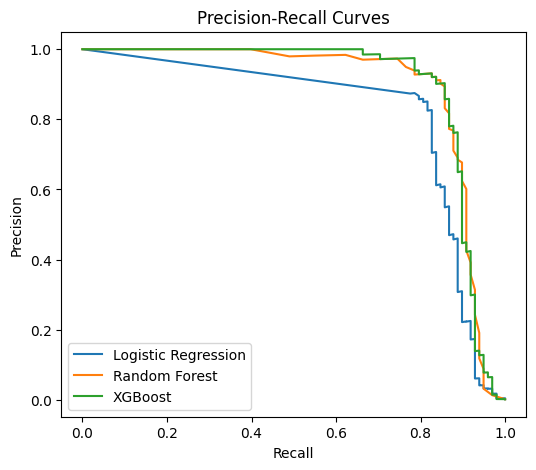

In [22]:
plt.figure(figsize=(6,5))

for name, model in models.items():
    prec, rec, _ = precision_recall_curve(Y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(rec, prec, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.show()